# 02 — the book at one second, every venue

`gold.book_top20` is the state at the *end* of each second, replayed from every venue frame (Kraken's checksum-verified). Pick an instant and look at BTC across venues.

In [1]:
from k2lake import connect, pin, SCALE
con = connect()
PIN = pin(con)   # every query below reads these snapshot ids, never the moving head
AT = con.sql("SELECT max(second) - INTERVAL 30 MINUTE FROM pinned.gold_book_top20").fetchone()[0]
print('at', AT)

pinned 18 tables at commit b12cff9
  audit.checks                 4558366752866520299
  gold.bars                    1589136844755948459
  gold.bbo_1s                  1578478823608857678
  gold.book_state              6881440282983849882
  gold.book_top20              1206037850593976770
  gold.dim_instrument          1768279322099994693
  gold.dim_venue               4191380317728821135
  gold.ohlcv_1d                1579946688158752964
  gold.ohlcv_1h                2397688695969945394
  gold.ohlcv_1m                1622213366608023449
  gold.ohlcv_5m                1666460790140246036
  gold.trades                  1348216816157062508
  silver.book_binance          7922581822436893978
  silver.book_coinbase         5196050954894723418
  silver.book_kraken           9210612890945089666
  silver.trades_binance        3528392281922118482
  silver.trades_coinbase       7144589879523206615
  silver.trades_kraken         264358488000747777
at 2026-08-27 04:45:21+00:00


In [2]:
con.sql(f"""
SELECT exchange, canonical_symbol, second, depth, checksum_ok,
       bid_px_e8[1] / 100000000 AS bid, bid_qty_e8[1] / 100000000 AS bid_qty,
       ask_px_e8[1] / 100000000 AS ask, ask_qty_e8[1] / 100000000 AS ask_qty
FROM pinned.gold_book_top20
WHERE canonical_symbol LIKE 'BTC/%' AND second = TIMESTAMP '{AT}'
ORDER BY exchange
""").show()

┌──────────┬──────────────────┬──────────────────────────┬───────┬─────────────┬──────────┬────────────┬──────────┬────────────┐
│ exchange │ canonical_symbol │          second          │ depth │ checksum_ok │   bid    │  bid_qty   │   ask    │  ask_qty   │
│ varchar  │     varchar      │ timestamp with time zone │ int32 │   boolean   │  double  │   double   │  double  │   double   │
├──────────┼──────────────────┼──────────────────────────┼───────┼─────────────┼──────────┼────────────┼──────────┼────────────┤
│ binance  │ BTC/USDT         │ 2026-08-27 04:45:21+00   │    20 │ NULL        │ 78813.99 │    1.31985 │  78814.0 │    1.08471 │
│ coinbase │ BTC/USD          │ 2026-08-27 04:45:21+00   │    20 │ NULL        │  78798.7 │ 0.07695517 │ 78798.71 │ 0.04252237 │
│ kraken   │ BTC/USD          │ 2026-08-27 04:45:21+00   │    20 │ true        │  78798.1 │ 1.64914667 │  78798.2 │  0.0014759 │
└──────────┴──────────────────┴──────────────────────────┴───────┴─────────────┴──────────┴──────

The whole ladder for one venue — 20 levels a side, quantities in base units. `unnest` turns the four arrays into rows.

In [3]:
con.sql(f"""
WITH b AS (SELECT * FROM pinned.gold_book_top20 WHERE exchange = 'kraken' AND canonical_symbol = 'BTC/USD' AND second = TIMESTAMP '{AT}')
SELECT i AS level, bid_qty_e8[i] / 100000000 AS bid_qty, bid_px_e8[i] / 100000000 AS bid, ask_px_e8[i] / 100000000 AS ask, ask_qty_e8[i] / 100000000 AS ask_qty
FROM b, range(1, 21) r(i)
WHERE i <= depth ORDER BY i
""").show(max_rows=20)

┌───────┬────────────┬─────────┬─────────┬────────────┐
│ level │  bid_qty   │   bid   │   ask   │  ask_qty   │
│ int64 │   double   │ double  │ double  │   double   │
├───────┼────────────┼─────────┼─────────┼────────────┤
│     1 │ 1.64914667 │ 78798.1 │ 78798.2 │  0.0014759 │
│     2 │ 0.63453779 │ 78797.5 │ 78798.6 │    5.1e-05 │
│     3 │ 0.63454619 │ 78796.4 │ 78800.2 │ 0.04399102 │
│     4 │ 0.01529872 │ 78795.0 │ 78800.3 │       0.11 │
│     5 │    5.1e-05 │ 78794.7 │ 78802.5 │    5.1e-05 │
│     6 │ 0.04399102 │ 78793.9 │ 78803.7 │ 0.01629197 │
│     7 │ 0.19034965 │ 78793.8 │ 78804.1 │ 0.00446635 │
│     8 │ 0.01269136 │ 78793.7 │ 78804.4 │ 0.01273964 │
│     9 │ 0.06029417 │ 78793.5 │ 78805.3 │ 0.05449028 │
│    10 │ 0.24623872 │ 78792.6 │ 78805.4 │   0.182496 │
│    11 │ 0.63457934 │ 78792.3 │ 78806.4 │    5.1e-05 │
│    12 │ 0.19034101 │ 78792.1 │ 78807.9 │ 0.18941453 │
│    13 │    5.1e-05 │ 78790.8 │ 78808.0 │ 0.63445353 │
│    14 │ 0.58454015 │ 78790.4 │ 78810.4 │    5.

Spread and imbalance over the surrounding hour, from `gold.bbo_1s` (the same arithmetic ClickHouse's `gold.bbo_live` applies on read).

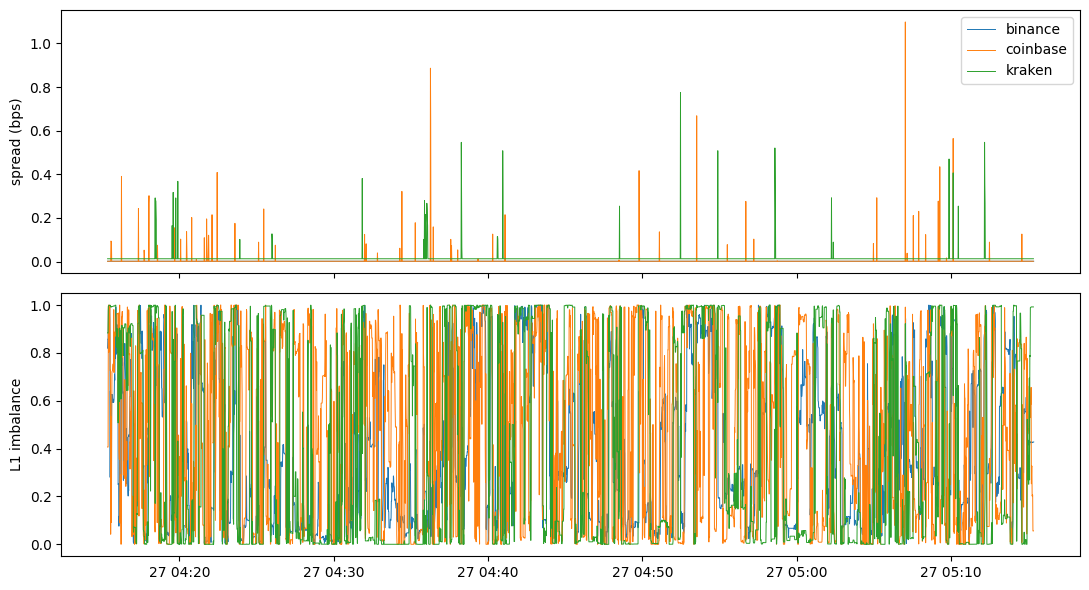

In [4]:
import matplotlib.pyplot as plt
df = con.sql(f"""
SELECT exchange, second, spread_bps, imbalance FROM pinned.gold_bbo_1s
WHERE canonical_symbol LIKE 'BTC/%' AND second BETWEEN TIMESTAMP '{AT}' - INTERVAL 30 MINUTE AND TIMESTAMP '{AT}' + INTERVAL 30 MINUTE
ORDER BY exchange, second
""").df()
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ex, g in df.groupby('exchange'):
    ax[0].plot(g['second'], g['spread_bps'], label=ex, lw=0.7)
    ax[1].plot(g['second'], g['imbalance'], label=ex, lw=0.7)
ax[0].set_ylabel('spread (bps)'); ax[1].set_ylabel('L1 imbalance'); ax[0].legend(); plt.tight_layout()